# 数据清洗与预处理

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os


# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示符号
#修改相对路径位置
os.chdir(r'C:\Users\李世昌\PycharmProjects\PythonProject')

读取数据

In [4]:
with open('./main/resident_evil_requiem_reviews.json', 'r', encoding='utf-8') as f:
    reviews=json.load(f)
df=pd.DataFrame(reviews)
df

,publish_date,content,recommendation,hours,player_level,owned_games
0,2026-02-28,还行，看里昂一路杀过来确实爽。,推荐,13.2,29,188
1,2026-02-28,里昂男神重返浣熊市，支持支持还是tm的支持,推荐,10.9,7,166
2,2026-02-28,作为重置系列全白金的小资历，发表一下个人对这一作的拙见，仅供参考\n首先里昂格蕾丝双线剧情，...,推荐,21.9,10,169
3,2026-02-28,十个小时丢档三次，OK，我真的只能差评，重新打三次幸好中途有一点退出的地方，不然我玩毛线,不推荐,15.0,21,180
4,2026-02-28,不如影之刃·············零,推荐,2.7,12,71
...,...,...,...,...,...,...
3508,2026-02-27,保时捷2026年度最佳广告,推荐,3.6,5,64
3509,2026-02-27,我不管 有三光就是超级好评给上,推荐,12.6,8,17
3510,2026-02-27,Support simplified Chinese support you,推荐,0.9,33,92
3511,2026-02-27,B.O.W最严厉的父亲,推荐,2.8,37,146


清洗评论文本

In [6]:
def clean_text(text):
    # 清洗，移除特殊字符（使用Python re模块支持的语法）
    text = re.sub(r'[\s\W_]+', ' ', text)
    # 清洗，移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df['clean_content']=df['content'].apply(clean_text)
#去重,去除空值
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df

,publish_date,content,recommendation,hours,player_level,owned_games,clean_content
0,2026-02-28,还行，看里昂一路杀过来确实爽。,推荐,13.2,29,188,还行 看里昂一路杀过来确实爽
1,2026-02-28,里昂男神重返浣熊市，支持支持还是tm的支持,推荐,10.9,7,166,里昂男神重返浣熊市 支持支持还是tm的支持
2,2026-02-28,作为重置系列全白金的小资历，发表一下个人对这一作的拙见，仅供参考\n首先里昂格蕾丝双线剧情，...,推荐,21.9,10,169,作为重置系列全白金的小资历 发表一下个人对这一作的拙见 仅供参考 首先里昂格蕾丝双线剧情 来...
3,2026-02-28,十个小时丢档三次，OK，我真的只能差评，重新打三次幸好中途有一点退出的地方，不然我玩毛线,不推荐,15.0,21,180,十个小时丢档三次 OK 我真的只能差评 重新打三次幸好中途有一点退出的地方 不然我玩毛线
4,2026-02-28,不如影之刃·············零,推荐,2.7,12,71,不如影之刃 零
...,...,...,...,...,...,...,...
3508,2026-02-27,保时捷2026年度最佳广告,推荐,3.6,5,64,保时捷2026年度最佳广告
3509,2026-02-27,我不管 有三光就是超级好评给上,推荐,12.6,8,17,我不管 有三光就是超级好评给上
3510,2026-02-27,Support simplified Chinese support you,推荐,0.9,33,92,Support simplified Chinese support you
3511,2026-02-27,B.O.W最严厉的父亲,推荐,2.8,37,146,B O W最严厉的父亲


In [24]:
#调用大模型api接口,用ai对清洗后的文本自动分类、自动判断情感倾向
from openai import OpenAI
import os
system_set="""
你是一个对游戏《生化危机》的评价文本进行评价分类的助手，你将接收到一条游戏评论，请你评论进行分类
分类范围：[画面，剧情，玩法，音效，优化，价格，情怀，其他]
示例输入：
十个小时丢档三次，OK，我真的只能差评，重新打三次幸好中途有一点退出的地方，不然我玩毛线
输出：
优化

示例输入：
里昂男神重返浣熊市，支持支持还是tm的支持
输出：
情怀

注意：分类范围优先考虑上述给出的几个范围关键词，严格按照示例格式输出每条评论最相关的分类关键词
"""
def sort(text):
    client=OpenAI(base_url='https://api.deepseek.com',api_key=os.getenv('DEEPSEEK_KEY'))
    responses=client.chat.completions.create(
        model='deepseek-chat',
        temperature=0.5,
        messages=[{'role':'system','content':system_set},
                  {'role':'user','content':text}
                  ])
    response=responses.choices[0].message.content
    return response

情怀


调用分类函数对文本进行分类

In [25]:
df['category']=df['clean_content'].apply(sort)

In [3]:
df=pd.read_csv('./main/ai_process.csv')
df

,Unnamed: 0,publish_date,content,recommendation,hours,player_level,owned_games,clean_content,category
0,0,2026-02-28,还行，看里昂一路杀过来确实爽。,推荐,13.2,29,188,还行 看里昂一路杀过来确实爽,情怀
1,1,2026-02-28,里昂男神重返浣熊市，支持支持还是tm的支持,推荐,10.9,7,166,里昂男神重返浣熊市 支持支持还是tm的支持,情怀
2,2,2026-02-28,作为重置系列全白金的小资历，发表一下个人对这一作的拙见，仅供参考\n首先里昂格蕾丝双线剧情，...,推荐,21.9,10,169,作为重置系列全白金的小资历 发表一下个人对这一作的拙见 仅供参考 首先里昂格蕾丝双线剧情 来...,玩法
3,3,2026-02-28,十个小时丢档三次，OK，我真的只能差评，重新打三次幸好中途有一点退出的地方，不然我玩毛线,不推荐,15.0,21,180,十个小时丢档三次 OK 我真的只能差评 重新打三次幸好中途有一点退出的地方 不然我玩毛线,优化
4,4,2026-02-28,不如影之刃·············零,推荐,2.7,12,71,不如影之刃 零,其他
...,...,...,...,...,...,...,...,...,...
3508,3508,2026-02-27,保时捷2026年度最佳广告,推荐,3.6,5,64,保时捷2026年度最佳广告,其他
3509,3509,2026-02-27,我不管 有三光就是超级好评给上,推荐,12.6,8,17,我不管 有三光就是超级好评给上,情怀
3510,3510,2026-02-27,Support simplified Chinese support you,推荐,0.9,33,92,Support simplified Chinese support you,其他
3511,3511,2026-02-27,B.O.W最严厉的父亲,推荐,2.8,37,146,B O W最严厉的父亲,剧情


分析情感倾向

In [4]:
def sentiment(text):
    senti='中性' #设置初始默认情感倾向
    if text=='推荐':
        senti='正面'
    elif text=='不推荐':
        senti='负面'
    return senti
df['sentiment']=df['recommendation'].apply(sentiment)
df

,Unnamed: 0,publish_date,content,recommendation,hours,player_level,owned_games,clean_content,category,sentiment
0,0,2026-02-28,还行，看里昂一路杀过来确实爽。,推荐,13.2,29,188,还行 看里昂一路杀过来确实爽,情怀,正面
1,1,2026-02-28,里昂男神重返浣熊市，支持支持还是tm的支持,推荐,10.9,7,166,里昂男神重返浣熊市 支持支持还是tm的支持,情怀,正面
2,2,2026-02-28,作为重置系列全白金的小资历，发表一下个人对这一作的拙见，仅供参考\n首先里昂格蕾丝双线剧情，...,推荐,21.9,10,169,作为重置系列全白金的小资历 发表一下个人对这一作的拙见 仅供参考 首先里昂格蕾丝双线剧情 来...,玩法,正面
3,3,2026-02-28,十个小时丢档三次，OK，我真的只能差评，重新打三次幸好中途有一点退出的地方，不然我玩毛线,不推荐,15.0,21,180,十个小时丢档三次 OK 我真的只能差评 重新打三次幸好中途有一点退出的地方 不然我玩毛线,优化,负面
4,4,2026-02-28,不如影之刃·············零,推荐,2.7,12,71,不如影之刃 零,其他,正面
...,...,...,...,...,...,...,...,...,...,...
3508,3508,2026-02-27,保时捷2026年度最佳广告,推荐,3.6,5,64,保时捷2026年度最佳广告,其他,正面
3509,3509,2026-02-27,我不管 有三光就是超级好评给上,推荐,12.6,8,17,我不管 有三光就是超级好评给上,情怀,正面
3510,3510,2026-02-27,Support simplified Chinese support you,推荐,0.9,33,92,Support simplified Chinese support you,其他,正面
3511,3511,2026-02-27,B.O.W最严厉的父亲,推荐,2.8,37,146,B O W最严厉的父亲,剧情,正面


保存清洗加工后的表

In [5]:
df.to_csv('./main/processed_table.csv')

# 数据可视化

情感分布

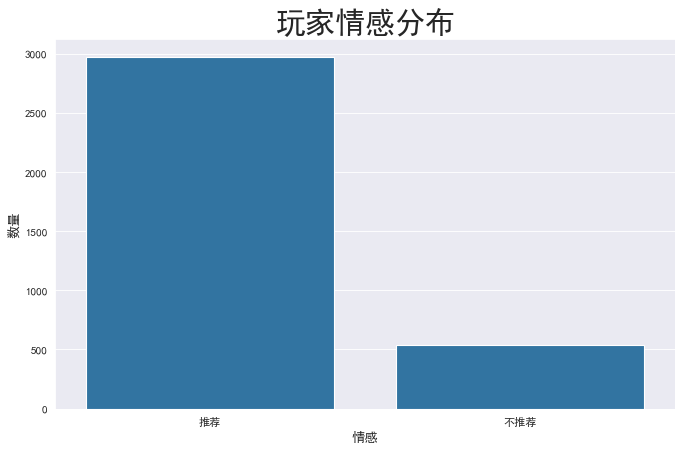

In [6]:
plt.figure(figsize=(10,6),dpi=80)
sentiment_distribute=df['recommendation'].value_counts()
sns.barplot(x=sentiment_distribute.index,y=sentiment_distribute.values)
plt.title('玩家情感分布',fontsize=27)
plt.xlabel('情感',fontsize=12)
plt.ylabel('数量',fontsize=12)
plt.savefig('./main/情感分布.png')
plt.show()

游戏时长分布

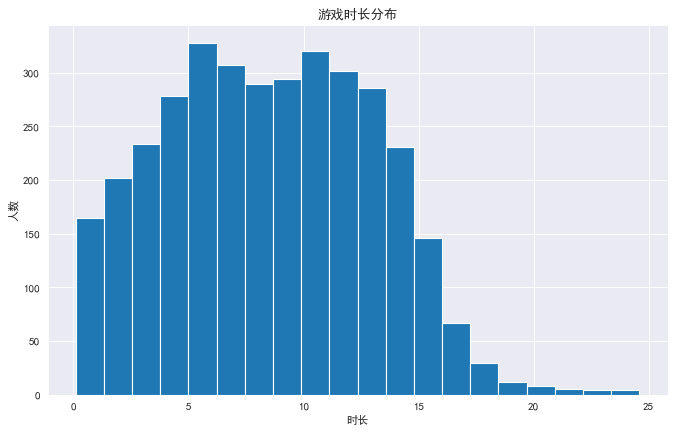

In [7]:
plt.figure(figsize=(10,6),dpi=80)
plt.hist(df['hours'],bins=20)
plt.title('游戏时长分布')
plt.xlabel('时长')
plt.ylabel('人数')
plt.savefig('./main/游戏时长分布.png')
plt.show()

玩家等级分布

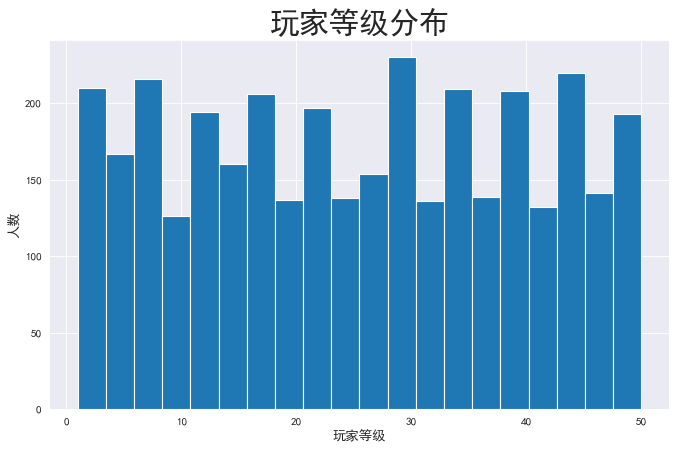

In [8]:
plt.figure(figsize=(10,6),dpi=80)
plt.hist(df['player_level'],bins=20)
plt.title('玩家等级分布',fontsize=27)
plt.xlabel('玩家等级',fontsize=12)
plt.ylabel('人数',fontsize=12)
plt.savefig('./main/玩家等级分布.png')
plt.show()

拥有游戏数量分布

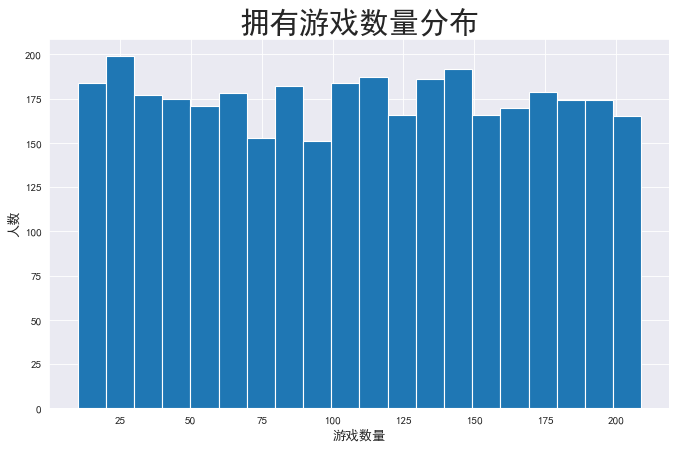

In [9]:
plt.figure(figsize=(10,6),dpi=80)
plt.hist(df['owned_games'],bins=20)
plt.title('拥有游戏数量分布',fontsize=27)
plt.xlabel('游戏数量',fontsize=12)
plt.ylabel('人数',fontsize=12)
plt.savefig('./main/拥有游戏数量分布.png')
plt.show()

评论类别分布

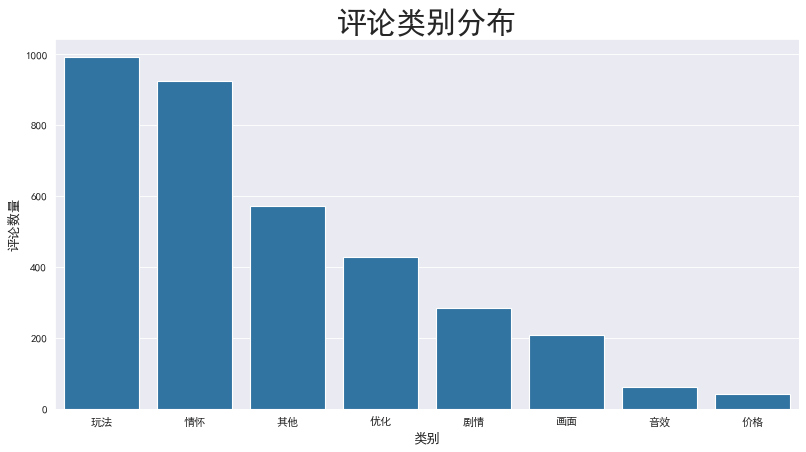

In [10]:
plt.figure(figsize=(12,6),dpi=80)
class_distribute=df['category'].value_counts()
sns.barplot(x=class_distribute.index,y=class_distribute.values)
plt.title('评论类别分布',fontsize=27)
plt.xlabel('类别',fontsize=12)
plt.ylabel('评论数量',fontsize=12)
plt.savefig('./main/评论类别分布.png')
plt.show()

情感--分类交叉分析

<Figure size 1920x960 with 0 Axes>

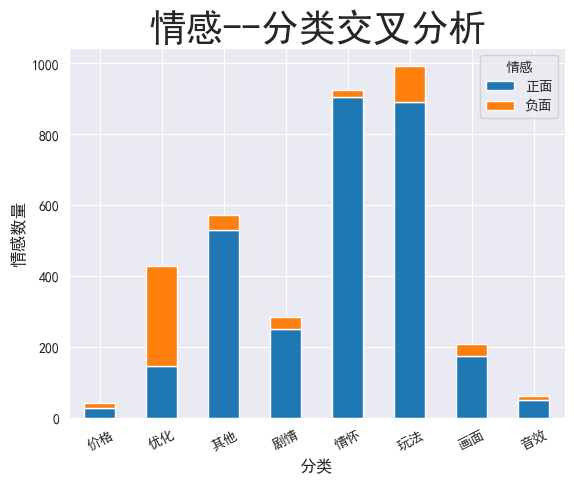

In [11]:
plt.figure(figsize=(12,6),dpi=160)
cross=pd.crosstab(df['category'],df['sentiment'])
cross.plot(kind='bar',stacked=True)
plt.title('情感--分类交叉分析',fontsize=27)
plt.xlabel('分类',fontsize=12)
plt.ylabel('情感数量',fontsize=12)
plt.legend(title='情感')
plt.xticks(rotation=27)
plt.savefig('./main/情感_分类交叉分析.png')
plt.show()

# 统计分析

In [12]:
total=df['sentiment'].count() #共计3513条评论
positive=(df['sentiment']=='正面').sum()
negative=(df['sentiment']=='负面').sum()
neutral=(df['sentiment']=='中性').sum()

print(f'总评论数:{total}')
print(f'正面评论数:{positive} 占比{(positive/total)*100:.1f}%')
print(f'负面评论数:{negative} 占比{(negative/total)*100:.1f}%')
print(f'中性评论数:{neutral} 占比0')

总评论数:3513
正面评论数:2974 占比84.7%
负面评论数:539 占比15.3%
中性评论数:0 占比0


In [13]:
#分类统计
cate=df['category'].value_counts() #cate为series对象
for a in cate.index: #a:类别 b:该类别数量
    b=cate[a]
    print(f'{a}:{b} 占比{(b/total)*100:.1f}%')

玩法:993 占比28.3%
情怀:924 占比26.3%
其他:572 占比16.3%
优化:429 占比12.2%
剧情:284 占比8.1%
画面:208 占比5.9%
音效:62 占比1.8%
价格:41 占比1.2%
